In [19]:
print(df.columns.tolist())

['dist_code', 'year', 'state_code', 'state_name', 'dist_name', 'rice_area', 'rice_production', 'rice_yield', 'wheat_area', 'wheat_production', 'wheat_yield', 'kharif_sorghum_area', 'kharif_sorghum_production', 'kharif_sorghum_yield', 'rabi_sorghum_area', 'rabi_sorghum_production', 'rabi_sorghum_yield', 'sorghum_area', 'sorghum_production', 'sorghum_yield', 'pearl_millet_area', 'pearl_millet_production', 'pearl_millet_yield', 'maize_area', 'maize_production', 'maize_yield', 'finger_millet_area', 'finger_millet_production', 'finger_millet_yield', 'barley_area', 'barley_production', 'barley_yield', 'chickpea_area', 'chickpea_production', 'chickpea_yield', 'pigeonpea_area', 'pigeonpea_production', 'pigeonpea_yield', 'minor_pulses_area', 'minor_pulses_production', 'minor_pulses_yield', 'groundnut_area', 'groundnut_production', 'groundnut_yield', 'sesamum_area', 'sesamum_production', 'sesamum_yield', 'rapeseed_and_mustard_area', 'rapeseed_and_mustard_production', 'rapeseed_and_mustard_yield'

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# Load the CLEANED data
df = pd.read_csv("agri_cleaned_data.csv") 

# This shows you the first 5 rows to confirm everything looks good
df.head()

,dist_code,year,state_code,state_name,dist_name,rice_area,rice_production,rice_yield,wheat_area,wheat_production,...,sugarcane_yield,cotton_area,cotton_production,cotton_yield,fruits_area,vegetables_area,fruits_and_vegetables_area,potatoes_area,onion_area,fodder_area
0,1,1966,14,Chhattisgarh,Durg,548000.0,185000.0,337.59,44000.0,20000.0,...,1777.78,0.0,0.0,0.0,5950.0,6640.0,12590.0,10.0,600.0,470.0
1,1,1967,14,Chhattisgarh,Durg,547000.0,409000.0,747.71,50000.0,26000.0,...,1500.00,0.0,0.0,0.0,5770.0,7240.0,13020.0,10.0,560.0,1230.0
2,1,1968,14,Chhattisgarh,Durg,556300.0,468000.0,841.27,53700.0,30000.0,...,1000.00,0.0,0.0,0.0,5410.0,7400.0,12810.0,100.0,580.0,1020.0
3,1,1969,14,Chhattisgarh,Durg,563400.0,400800.0,711.40,49400.0,26500.0,...,1900.00,0.0,0.0,0.0,5520.0,7160.0,12690.0,10.0,560.0,840.0
4,1,1970,14,Chhattisgarh,Durg,571600.0,473600.0,828.55,44200.0,29000.0,...,2000.00,0.0,0.0,0.0,5450.0,7190.0,12640.0,20.0,520.0,420.0


C:\Users\asus\AppData\Local\Temp\ipykernel_22008\2097320460.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_7_rice.index, y=top_7_rice.values, palette="GnBu_d")


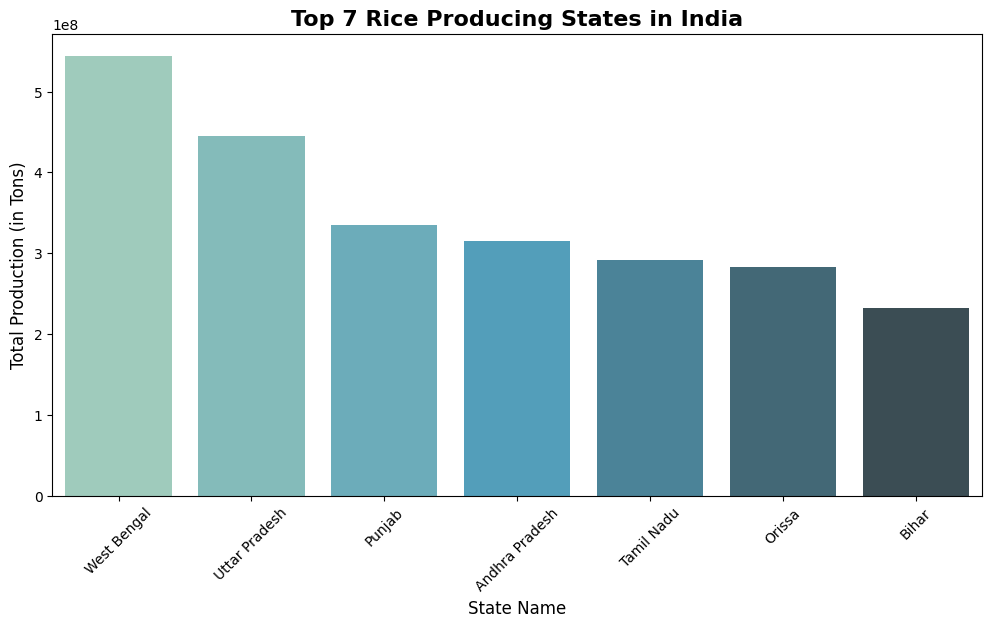

In [16]:
# 1. Top 7 RICE PRODUCTION State Data(Bar_plot)

top_7_rice = df.groupby('state_name')['rice_production'].sum().nlargest(7)

# 1.1 Create the Bar Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=top_7_rice.index, y=top_7_rice.values, palette="GnBu_d")

# 1.2 Add labels and title for professionalism
plt.title('Top 7 Rice Producing States in India', fontsize=16, fontweight='bold')
plt.xlabel('State Name', fontsize=12)
plt.ylabel('Total Production (in Tons)', fontsize=12)
plt.xticks(rotation=45) # Rotates state names so they don't overlap

# 1.3 Show the plot
plt.show()

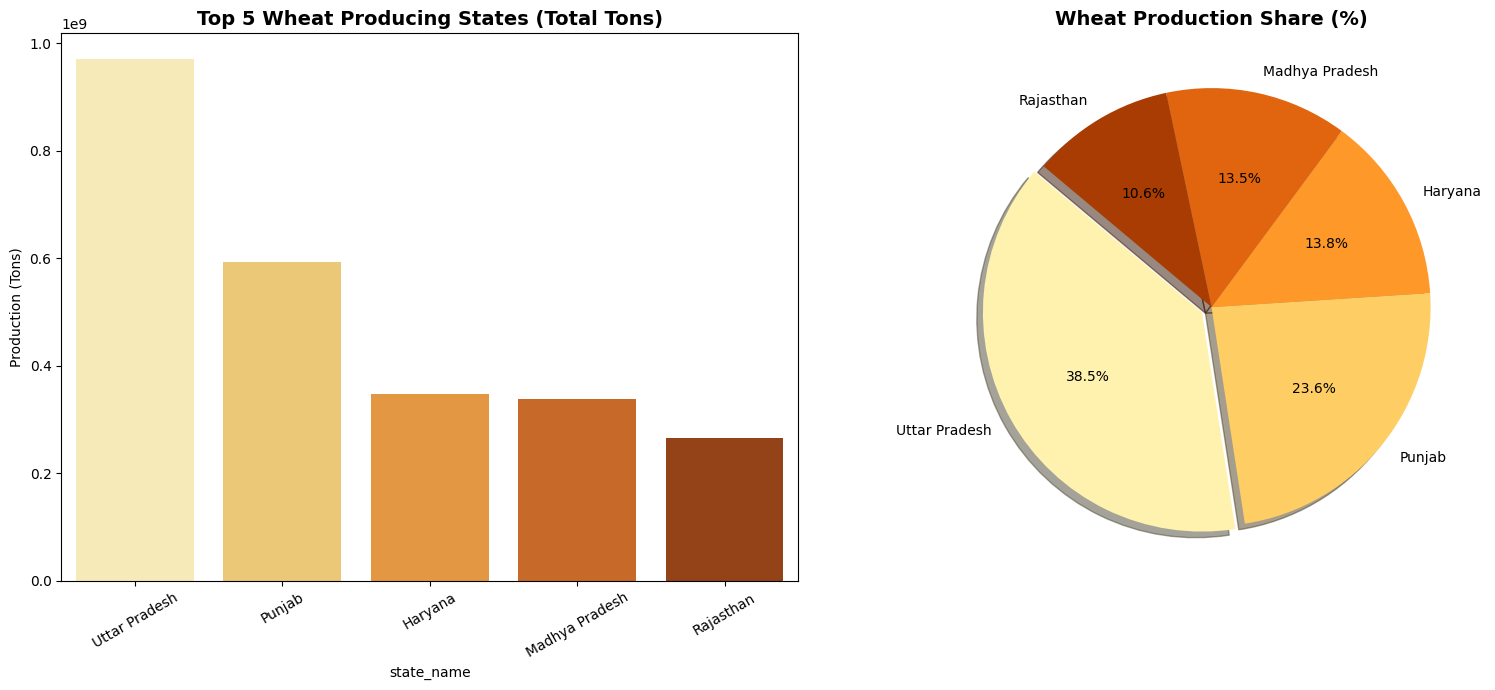

In [17]:
# 2. Filter and Group the Top 5 Wheat States
top_5_wheat = df.groupby('state_name')['wheat_production'].sum().nlargest(5)

# 2.1 Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- PLOT 1: Bar Chart (The Ranking) ---
sns.barplot(x=top_5_wheat.index, y=top_5_wheat.values, ax=ax1, palette="YlOrBr", hue=top_5_wheat.index, legend=False)
ax1.set_title('Top 5 Wheat Producing States (Total Tons)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Production (Tons)')
ax1.tick_params(axis='x', rotation=30)

# --- PLOT 2: Pie Chart (The Percentage Share) ---
# We use the same colors for consistency
colors = sns.color_palette("YlOrBr", len(top_5_wheat))
top_5_wheat.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=140, colors=colors, explode=[0.05, 0, 0, 0, 0], shadow=True)
ax2.set_title('Wheat Production Share (%)', fontsize=14, fontweight='bold')
ax2.set_ylabel('') # Clean up the default y-label

plt.tight_layout()
plt.show()

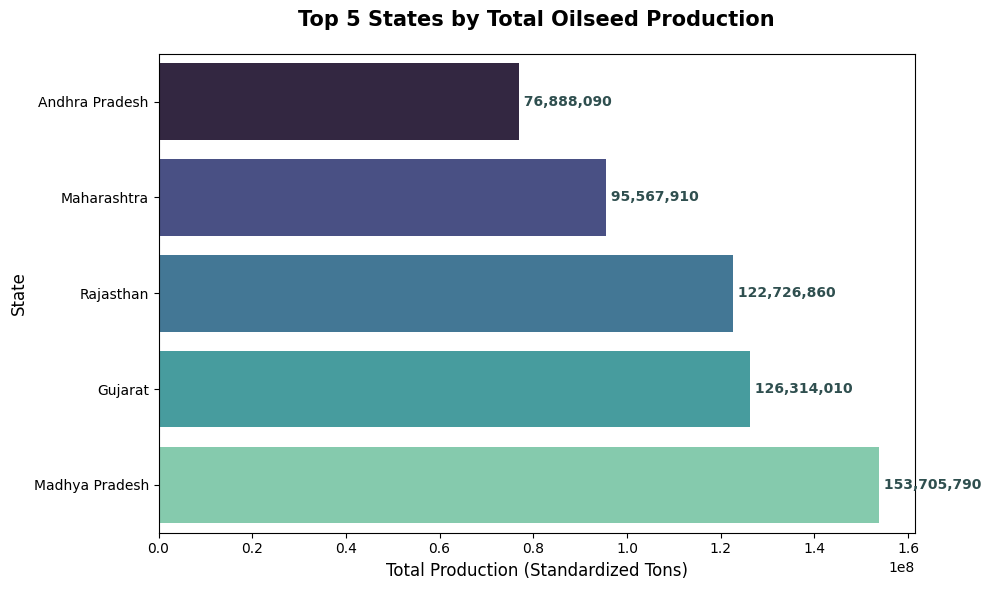

In [20]:
# 3. Group and Sort the Top 5 Oilseed States
# Note: Ensure 'total_oilseeds_production' matches your cleaned column name
top_5_oilseeds = df.groupby('state_name')['oilseeds_production'].sum().nlargest(5).sort_values(ascending=True)

# 3.1 Create the Horizontal Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_5_oilseeds.values, y=top_5_oilseeds.index, palette="mako", hue=top_5_oilseeds.index, legend=False)

# 3.2 Add Professional Styling
plt.title('Top 5 States by Total Oilseed Production', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Total Production (Standardized Tons)', fontsize=12)
plt.ylabel('State', fontsize=12)

# 3.3 Add Value Labels (The "Pro" Touch)
# This puts the actual number at the end of each bar
for i, v in enumerate(top_5_oilseeds.values):
    plt.text(v, i, f' {v:,.0f}', va='center', fontweight='bold', color='darkslategray')

plt.tight_layout()
plt.show()

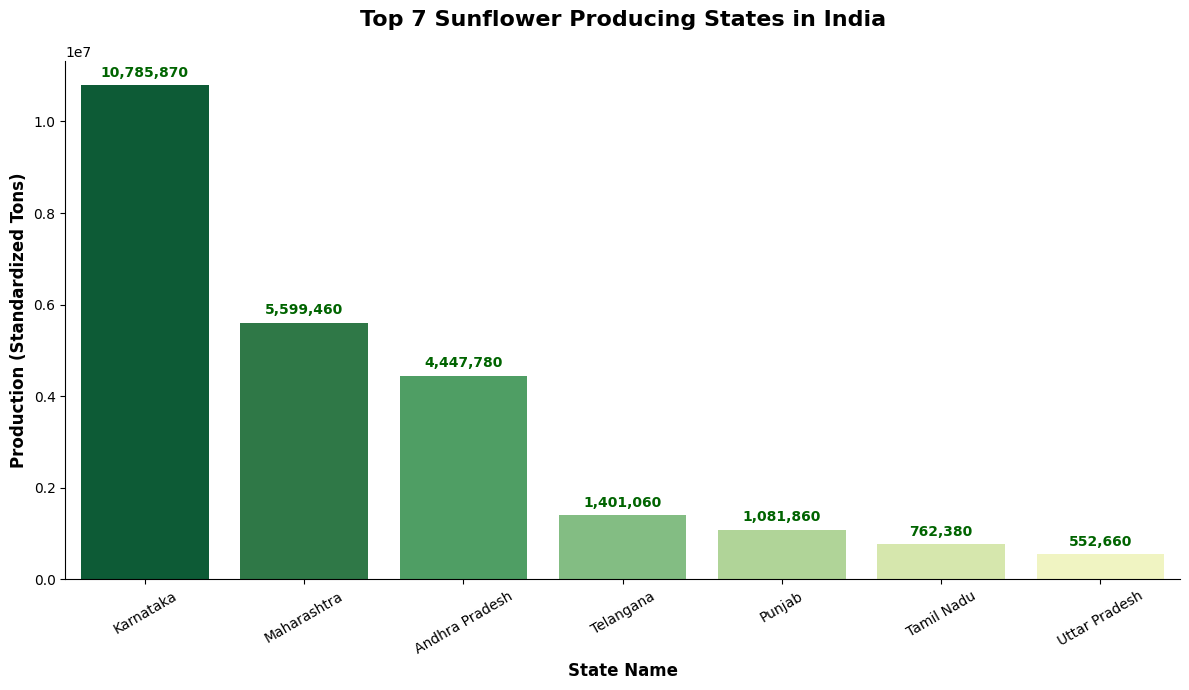

In [22]:
# 4. Group and Sort the Top 7 Sunflower States

top_7_sunflower = df.groupby('state_name')['sunflower_production'].sum().nlargest(7)

# 4.1 Create the Vertical Bar Plot
plt.figure(figsize=(12, 7))
plot = sns.barplot(x=top_7_sunflower.index, y=top_7_sunflower.values, 
                   palette="YlGn_r", hue=top_7_sunflower.index, legend=False)

# 4.2 Add Professional Styling
plt.title('Top 7 Sunflower Producing States in India', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('State Name', fontsize=12, fontweight='bold')
plt.ylabel('Production (Standardized Tons)', fontsize=12, fontweight='bold')
plt.xticks(rotation=30)

# 4.3 Add "Data Labels" on top of each bar (The "Executive" Touch)
for p in plot.patches:
    plot.annotate(format(p.get_height(), ',.0f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontweight='bold', color='darkgreen')

# 4.4 Remove the top and right borders for a modern look
sns.despine()

plt.tight_layout()
plt.show()

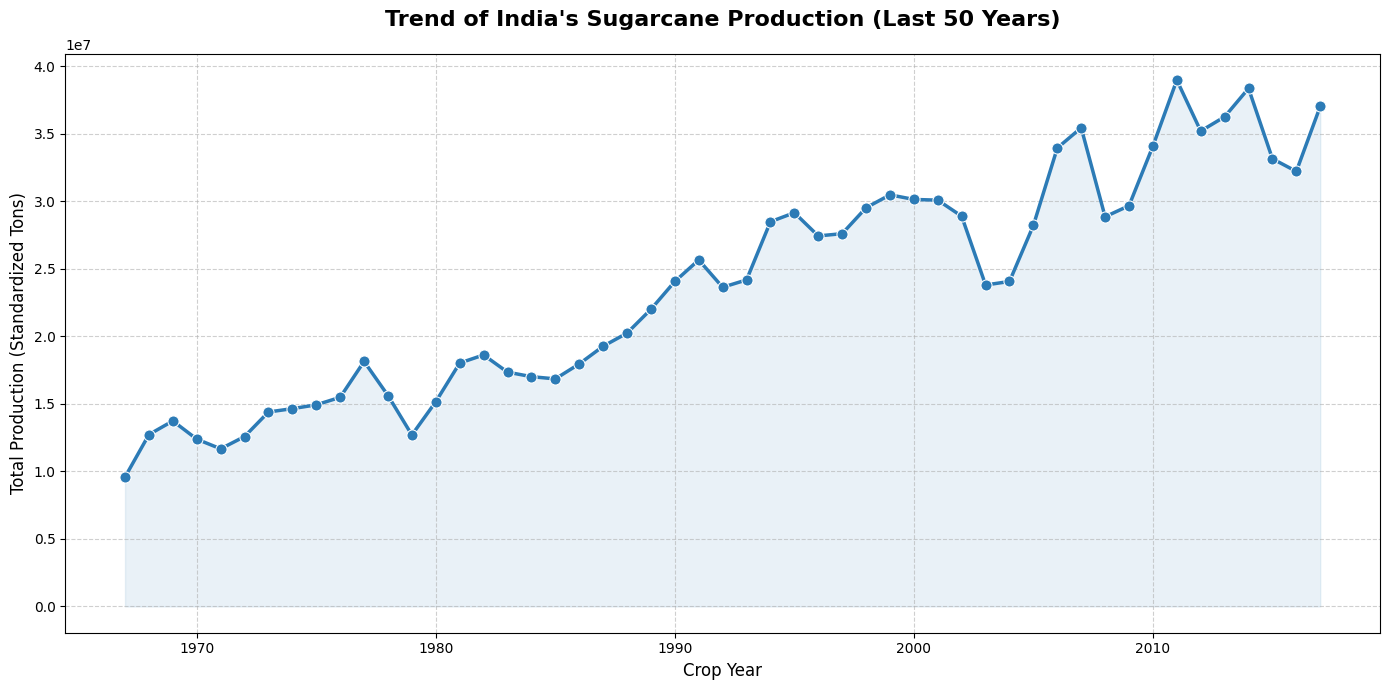

In [23]:
# 5.India's SUGARCANE PRODUCTION From Last 50 Years(Line_plot)

year_col = next((c for c in ['crop_year', 'year'] if c in df.columns), None)
sugar_col = next((c for c in ['sugarcane', 'sugarcane_production'] if c in df.columns), None)

if year_col and sugar_col:
    # 5.2 Group by Year and Sum Production
    yearly_sugar = df.groupby(year_col)[sugar_col].sum().reset_index()

    # 5.3 Filter for the last 50 years (if the data goes back that far)
    current_year = yearly_sugar[year_col].max()
    yearly_sugar = yearly_sugar[yearly_sugar[year_col] >= (current_year - 50)]

    # 5.4 Create the Line Plot
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=yearly_sugar, x=year_col, y=sugar_col, 
                 marker='o', color='#2c7bb6', linewidth=2.5, markersize=8)

    # 5.5 Add a "Trend Area" (Fill under the line for a professional look)
    plt.fill_between(yearly_sugar[year_col], yearly_sugar[sugar_col], color='#2c7bb6', alpha=0.1)

    # 5.6 Professional Styling
    plt.title("Trend of India's Sugarcane Production (Last 50 Years)", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Crop Year', fontsize=12)
    plt.ylabel('Total Production (Standardized Tons)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6) # Add a subtle grid for readability

    plt.tight_layout()
    plt.show()
else:
    print(f"Check your column names! Found: {df.columns.tolist()}")

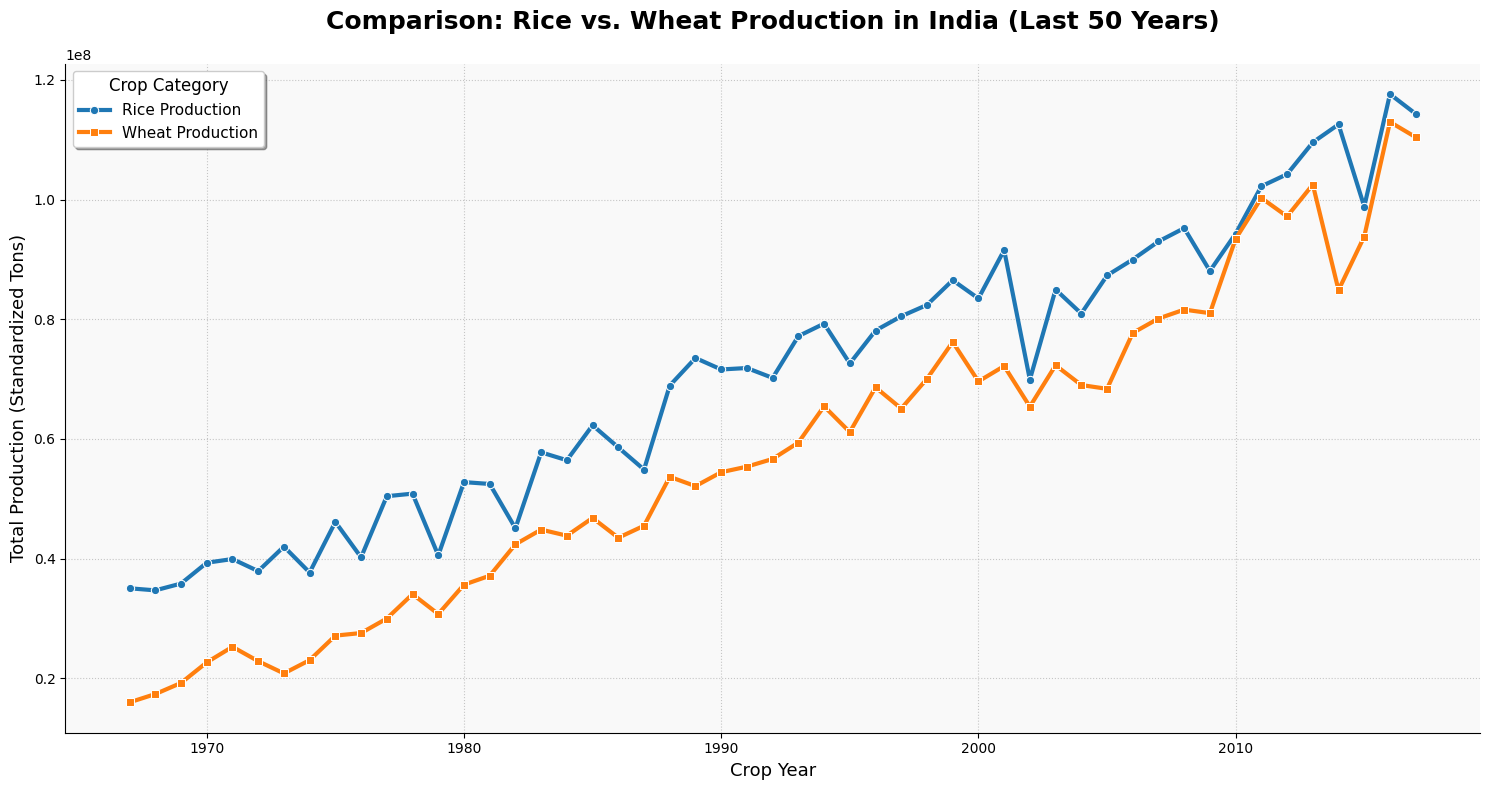

In [24]:
# 6. Rice Production Vs Wheat Production (Last 50y)

year_col = next((c for c in ['crop_year', 'year'] if c in df.columns), None)
rice_col = next((c for c in ['rice', 'rice_production'] if c in df.columns), None)
wheat_col = next((c for c in ['wheat', 'wheat_production'] if c in df.columns), None)

if all([year_col, rice_col, wheat_col]):
    # 6.1. Group by Year and Sum Production for both
    comparison_df = df.groupby(year_col)[[rice_col, wheat_col]].sum().reset_index()

    # 6.2 Filter for the last 50 years
    current_year = comparison_df[year_col].max()
    comparison_df = comparison_df[comparison_df[year_col] >= (current_year - 50)]

    # 6.3 Create the Figure
    plt.figure(figsize=(15, 8))

    # Plot Rice
    sns.lineplot(data=comparison_df, x=year_col, y=rice_col, label='Rice Production', 
                 color='#1f77b4', linewidth=3, marker='o', markersize=6)
    
    # Plot Wheat
    sns.lineplot(data=comparison_df, x=year_col, y=wheat_col, label='Wheat Production', 
                 color='#ff7f0e', linewidth=3, marker='s', markersize=6)

    # 6.4 Add Professional Styling
    plt.title('Comparison: Rice vs. Wheat Production in India (Last 50 Years)', 
              fontsize=18, fontweight='bold', pad=25)
    plt.xlabel('Crop Year', fontsize=13)
    plt.ylabel('Total Production (Standardized Tons)', fontsize=13)
    
    # Add a legend with a frame for clarity
    plt.legend(title="Crop Category", fontsize=11, title_fontsize='12', frameon=True, shadow=True)
    
    # Add a light grid and background color for "Executive" feel
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.gca().set_facecolor('#f9f9f9')

    # Remove the top and right spines
    sns.despine()

    plt.tight_layout()
    plt.show()
else:
    print(f"Check your column names! Found: {df.columns.tolist()}")

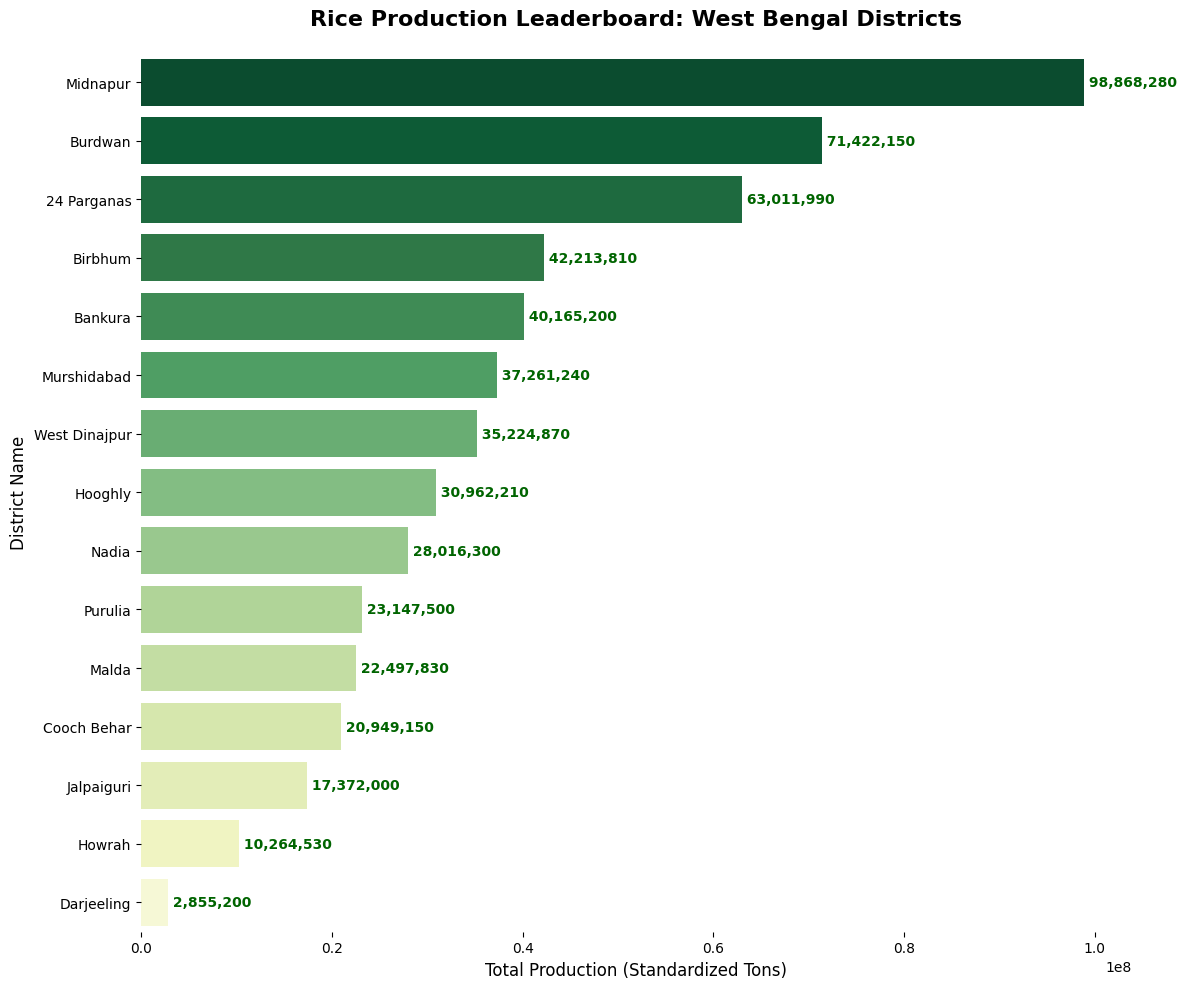

In [ ]:
# 7.Rice Production By West Bengal Districts (Filter data for West Bengal and group by District)

# We convert to title case just in case the data has mixed casing

wb_rice = df[df[''].str.title() == 'West Bengal']
district_ranking = wb_rice.groupby('dist_name')['rice_production'].sum().sort_values(ascending=False)

# 7.2 Create the Figure
plt.figure(figsize=(12, 10))

# 7.3 Plotting (Using a "Greens" palette to represent rice fields)
sns.barplot(x=district_ranking.values, y=district_ranking.index, 
            palette="YlGn_r", hue=district_ranking.index, legend=False)

# 7.4 Add Professional Styling
plt.title('Rice Production Leaderboard: West Bengal Districts', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Production (Standardized Tons)', fontsize=12)
plt.ylabel('District Name', fontsize=12)

# 7.5 Add Value Labels (The "Pro" Touch)state_name
for i, v in enumerate(district_ranking.values):
    plt.text(v, i, f' {v:,.0f}', va='center', fontsize=10, fontweight='bold', color='darkgreen')

# 7.6 Final Layout Cleanup
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

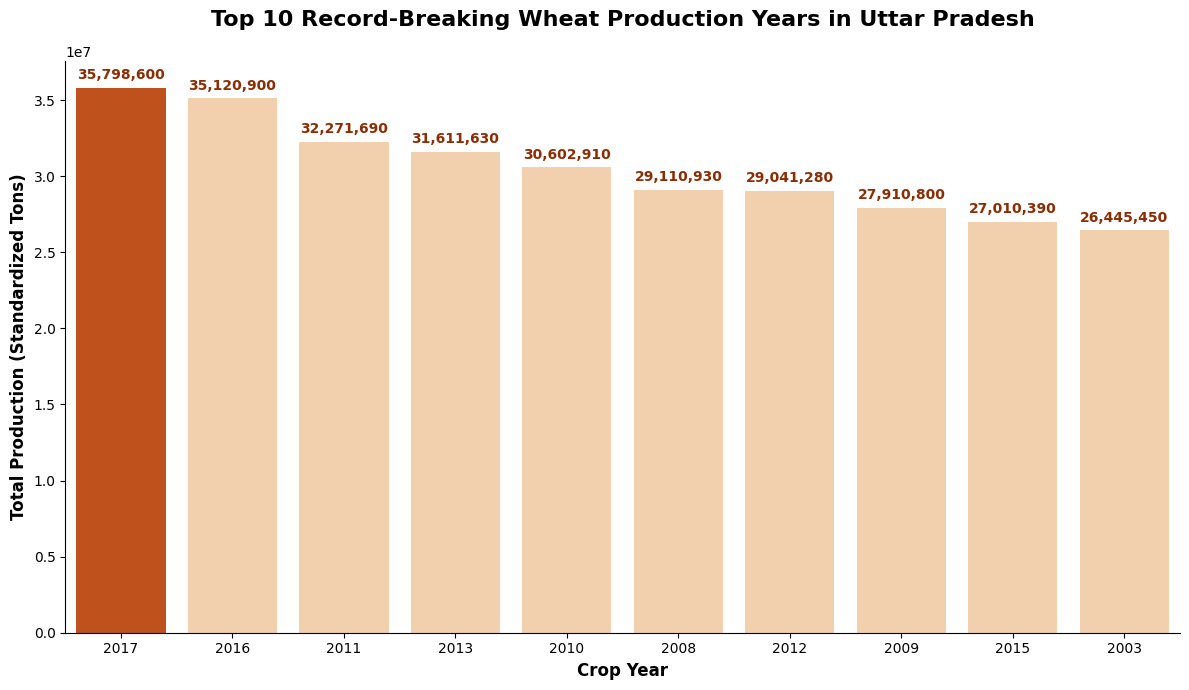

In [28]:
# 8. Top 10 Wheat Production Years From UP (Filter for Uttar Pradesh (UP) and ensure columns exist)

up_data = df[df['state_name'].str.upper() == 'UTTAR PRADESH']

# 8.1 Group by Year and sum Wheat Production
# Note: Using nlargest(10) to get the top 10 years
top_10_up_wheat = up_data.groupby('year')['wheat_production'].sum().nlargest(10).sort_values(ascending=False)

# 8.2 Create the Figure
plt.figure(figsize=(12, 7))

# 8.3 Plotting
# We use a 'Wistia' or 'Oranges' palette to represent the golden color of wheat
colors = ['#d94801' if (x == max(top_10_up_wheat.values)) else '#fdd0a2' for x in top_10_up_wheat.values]
plot = sns.barplot(x=top_10_up_wheat.index.astype(str), y=top_10_up_wheat.values, 
                   palette=colors, hue=top_10_up_wheat.index.astype(str), legend=False)

# 8.4 Add Professional Styling
plt.title('Top 10 Record-Breaking Wheat Production Years in Uttar Pradesh', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Crop Year', fontsize=12, fontweight='bold')
plt.ylabel('Total Production (Standardized Tons)', fontsize=12, fontweight='bold')

# 8.5 Add Data Labels on top of each bar
for p in plot.patches:
    plot.annotate(format(p.get_height(), ',.0f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontweight='bold', color='#8c2d04')

# 8.6 Modern Cleanup
sns.despine()
plt.tight_layout()
plt.show()

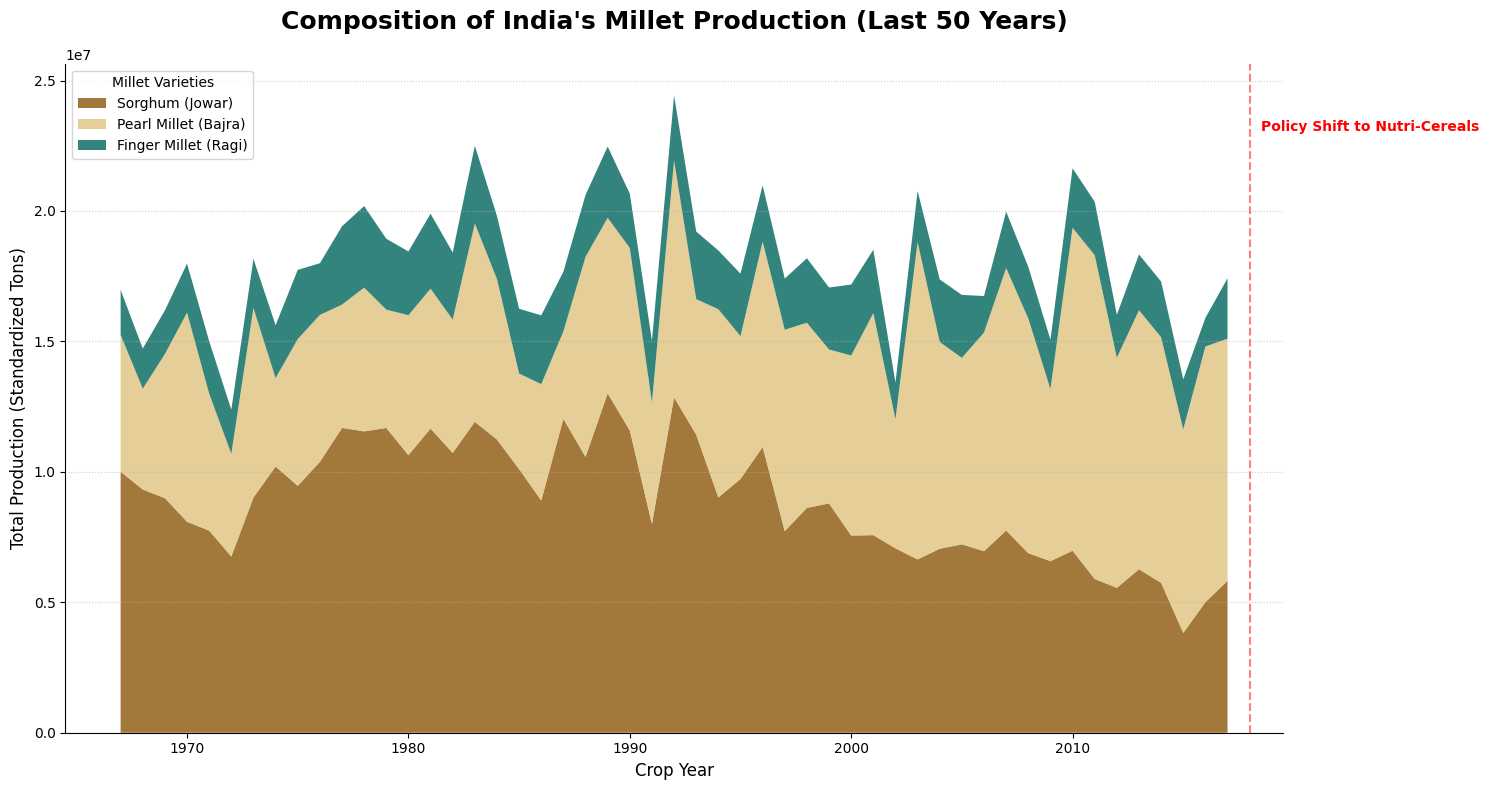

In [31]:
# 9. Millet Production (Last 50y)

millet_types = {
    'Sorghum (Jowar)': 'sorghum_production',
    'Pearl Millet (Bajra)': 'pearl_millet_production',
    'Finger Millet (Ragi)': 'finger_millet_production'
}

# Group by year and sum the specific columns
millet_trends = df.groupby('year')[list(millet_types.values())].sum().reset_index()

# 9.1 Filter for the last 50 years
current_year = millet_trends['year'].max()
millet_trends = millet_trends[millet_trends['year'] >= (current_year - 50)]

# 9.2 Plotting the Stacked Area Chart
plt.figure(figsize=(15, 8))
colors = ["#8c580adc", '#dfc27d', '#01665e'] # Professional Earth-Tone Palette

plt.stackplot(millet_trends['year'], 
              millet_trends['sorghum_production'], 
              millet_trends['pearl_millet_production'], 
              millet_trends['finger_millet_production'], 
              labels=millet_types.keys(), 
              colors=colors, alpha=0.8)

# 9.3 Professional Styling
plt.title("Composition of India's Millet Production (Last 50 Years)", fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Crop Year', fontsize=12)
plt.ylabel('Total Production (Standardized Tons)', fontsize=12)

# Add a vertical line to show the recent "Millets Revival" phase
plt.axvline(x=2018, color='red', linestyle='--', alpha=0.5)
plt.text(2018.5, plt.ylim()[1]*0.9, 'Policy Shift to Nutri-Cereals', color='red', fontweight='bold')

plt.legend(loc='upper left', title="Millet Varieties", frameon=True)
plt.grid(axis='y', linestyle=':', alpha=0.6)
sns.despine()

plt.tight_layout()
plt.show()

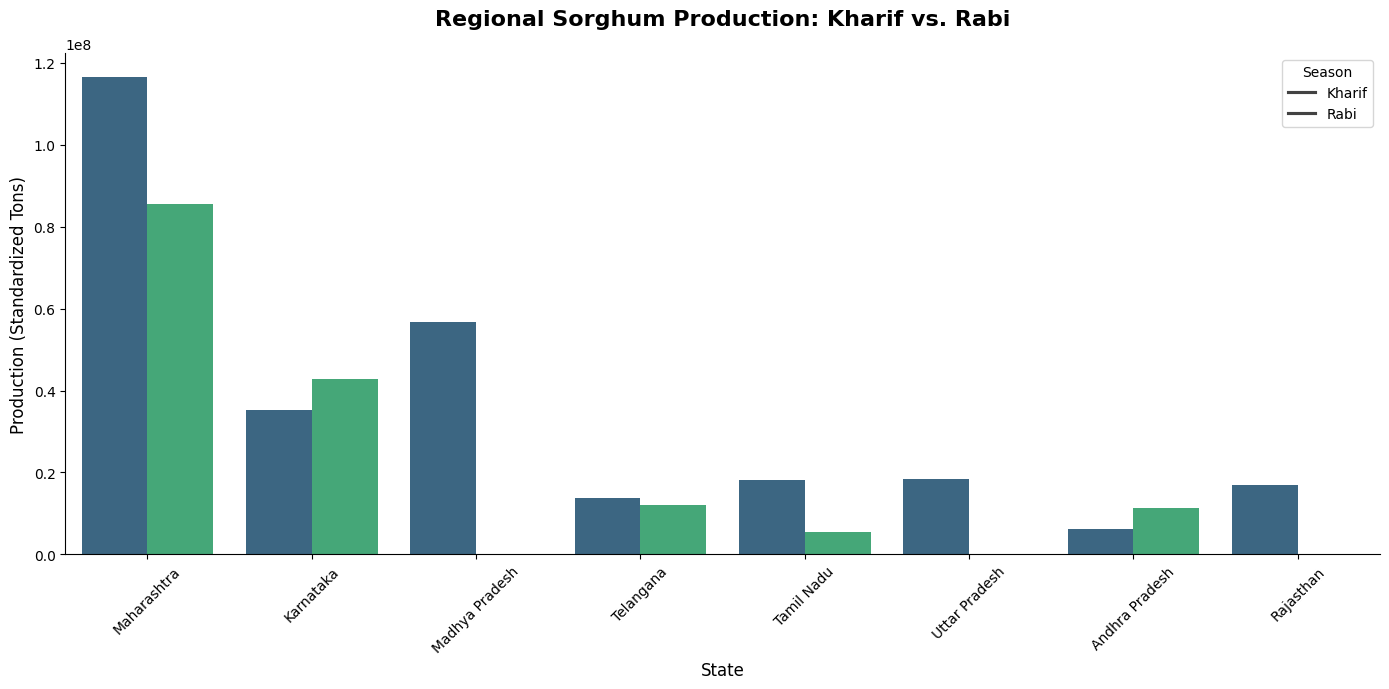

In [32]:
# 10. Sorghum Production (Kharif and Rabi) by Region

sorghum_data = df.groupby('state_name')[['kharif_sorghum_production', 'rabi_sorghum_production']].sum().reset_index()

# Sort by total production
sorghum_data['total'] = sorghum_data['kharif_sorghum_production'] + sorghum_data['rabi_sorghum_production']
sorghum_data = sorghum_data.sort_values(by='total', ascending=False).head(8) # Top 8 states

# 10.2 Reshape for Seaborn (Long format)
sorghum_melted = sorghum_data.melt(id_vars='state_name', 
                                    value_vars=['kharif_sorghum_production', 'rabi_sorghum_production'],
                                    var_name='Season', value_name='Production')

# 10.3 Create the Grouped Bar Chart
plt.figure(figsize=(14, 7))
sns.barplot(data=sorghum_melted, x='state_name', y='Production', hue='Season', palette='viridis')

# 10.4 Professional Styling
plt.title('Regional Sorghum Production: Kharif vs. Rabi', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Production (Standardized Tons)', fontsize=12)
plt.xlabel('State', fontsize=12)
plt.xticks(rotation=45)

# Modernizing Legend
plt.legend(title="Season", labels=['Kharif', 'Rabi'], frameon=True)
sns.despine()

plt.tight_layout()
plt.show()

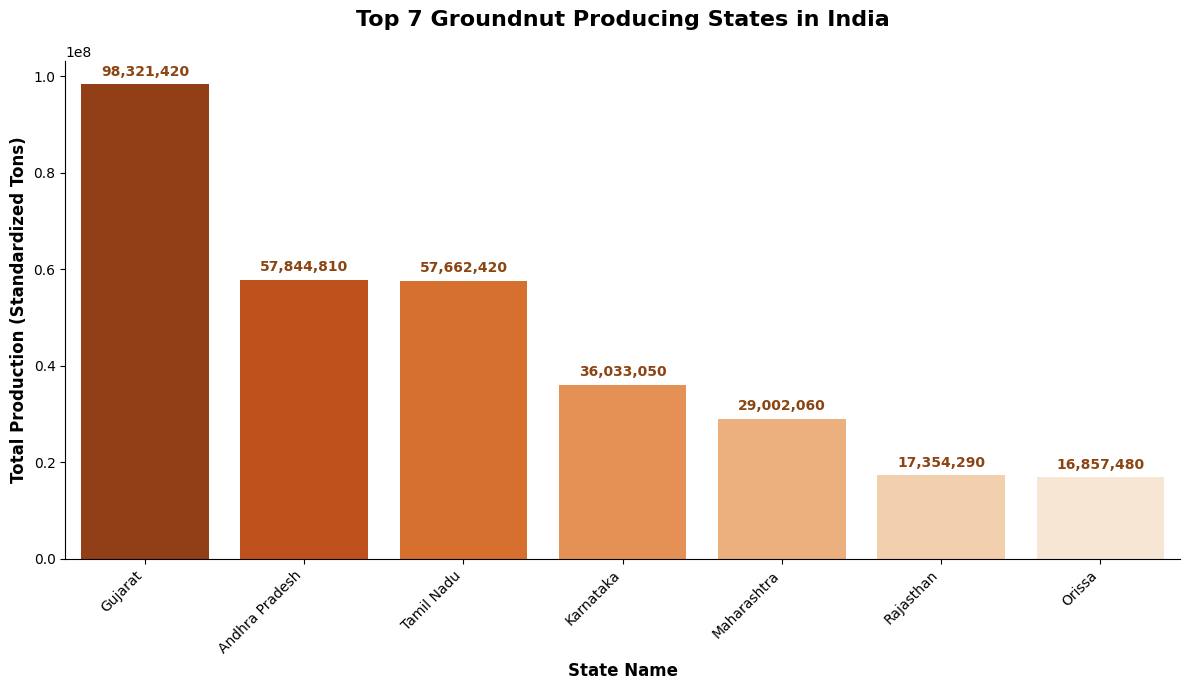

In [33]:
# 11. Top 7 States for Groundnut Production (Group and Sort the Top 7 Groundnut States)
top_7_groundnut = df.groupby('state_name')['groundnut_production'].sum().nlargest(7)

# 11.2 Create the Figure
plt.figure(figsize=(12, 7))

# 11.3 Plotting with a warm, professional palette
plot = sns.barplot(x=top_7_groundnut.index, y=top_7_groundnut.values, 
                   palette="Oranges_r", hue=top_7_groundnut.index, legend=False)

# 11.4 Professional Styling
plt.title('Top 7 Groundnut Producing States in India', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('State Name', fontsize=12, fontweight='bold')
plt.ylabel('Total Production (Standardized Tons)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# 11.5 Add "Data Labels" for Executive Clarity
for p in plot.patches:
    plot.annotate(format(p.get_height(), ',.0f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontweight='bold', color='saddlebrown')

# 11.6 Modern Clean-up
sns.despine()
plt.tight_layout()
plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_22008\418671197.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='state_name', y='soyabean_production', data=soy_data,


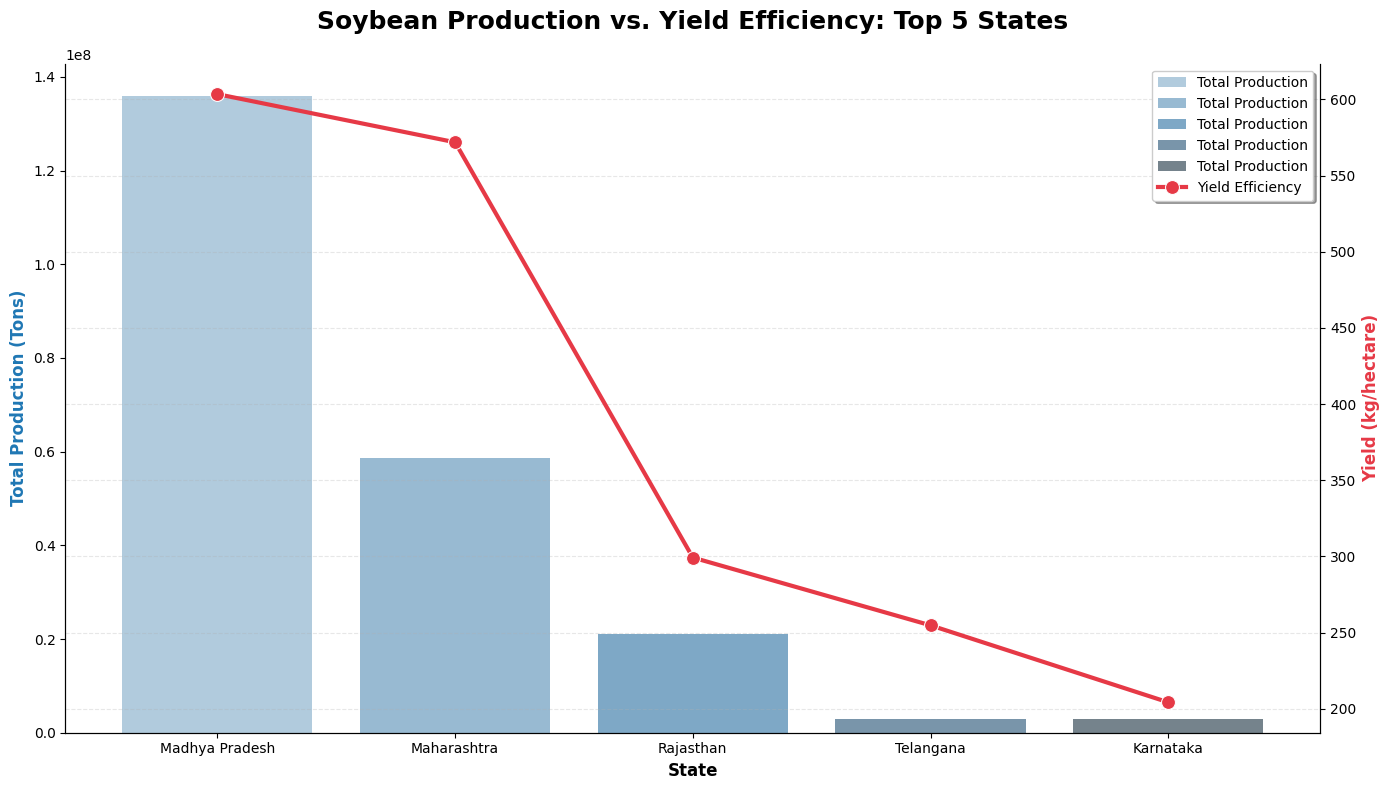

In [34]:
# 12. Soybean Production by Top 5 States and Yield Efficiency(Group by State and sum Production & mean Yield)

soy_data = df.groupby('state_name').agg({
    'soyabean_production': 'sum',
    'soyabean_yield': 'mean'
}).nlargest(5, 'soyabean_production').reset_index()

# 12.1 Create the Plot
fig, ax1 = plt.subplots(figsize=(14, 8))

# --- BAR CHART (Production) ---
sns.barplot(x='state_name', y='soyabean_production', data=soy_data, 
            ax=ax1, palette='Blues_d', alpha=0.7, label='Total Production')
ax1.set_ylabel('Total Production (Tons)', fontsize=12, fontweight='bold', color='#1f77b4')
ax1.set_xlabel('State', fontsize=12, fontweight='bold')

# --- LINE CHART (Yield Efficiency) ---
ax2 = ax1.twinx() # Create the second Y-axis
sns.lineplot(x='state_name', y='soyabean_yield', data=soy_data, 
             ax=ax2, color='#e63946', marker='o', linewidth=3, markersize=10, label='Yield Efficiency')
ax2.set_ylabel('Yield (kg/hectare)', fontsize=12, fontweight='bold', color='#e63946')

# 12.2. Professional Styling
plt.title('Soybean Production vs. Yield Efficiency: Top 5 States', fontsize=18, fontweight='bold', pad=25)

# Add Legend manually to combine both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', frameon=True, shadow=True)

# Remove top spine
sns.despine(right=False)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

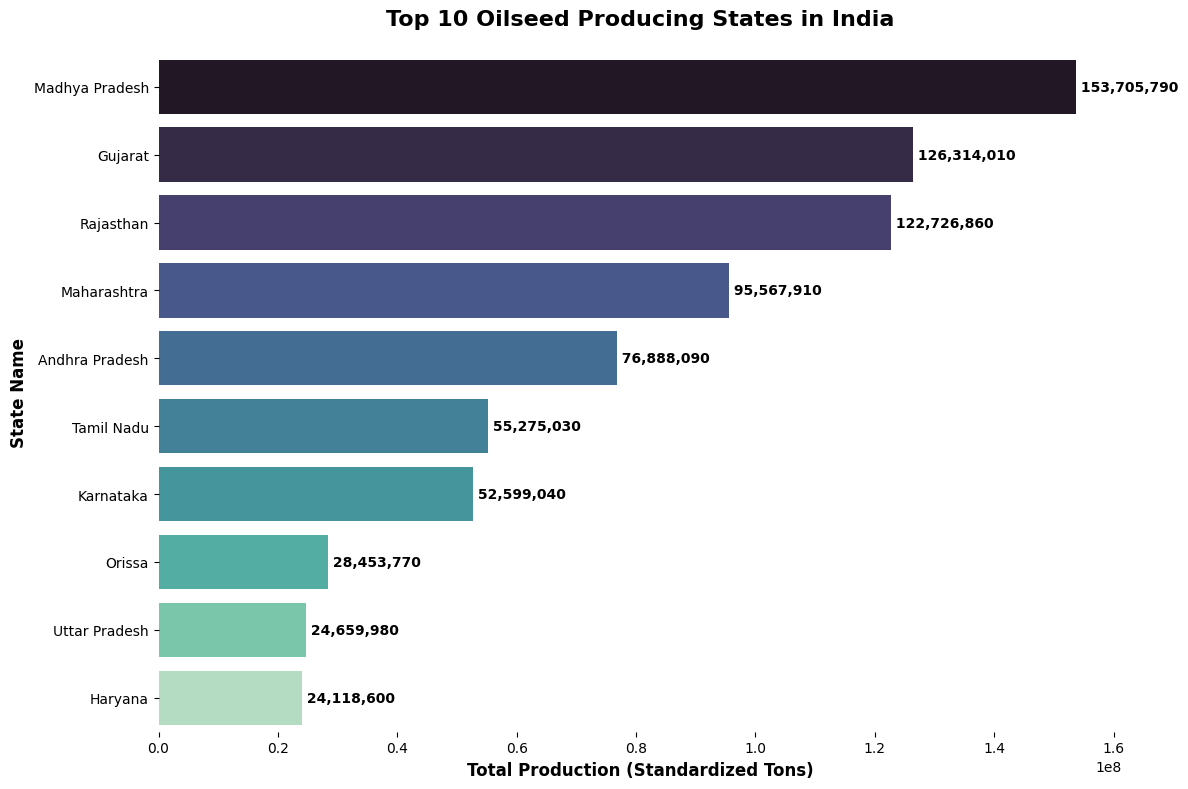

In [35]:
# 13. Oilseed Production in Major States(Group by state and sum production)

oilseed_data = df.groupby('state_name')['oilseeds_production'].sum().sort_values(ascending=False).head(10)

# 13.1. Create the Plot
plt.figure(figsize=(12, 8))

# 13.2. Use a soft, high-contrast palette ('mako')
sns.barplot(x=oilseed_data.values, y=oilseed_data.index, 
            palette="mako", hue=oilseed_data.index, legend=False)

# 13.3. Professional Styling
plt.title('Top 10 Oilseed Producing States in India', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Production (Standardized Tons)', fontsize=12, fontweight='bold')
plt.ylabel('State Name', fontsize=12, fontweight='bold')

# 13.4. Add Value Labels at the end of bars for "Executive" readability
for i, v in enumerate(oilseed_data.values):
    plt.text(v, i, f' {v:,.0f}', va='center', fontsize=10, fontweight='bold', color='black')

# 13.5. Clean the chart borders
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

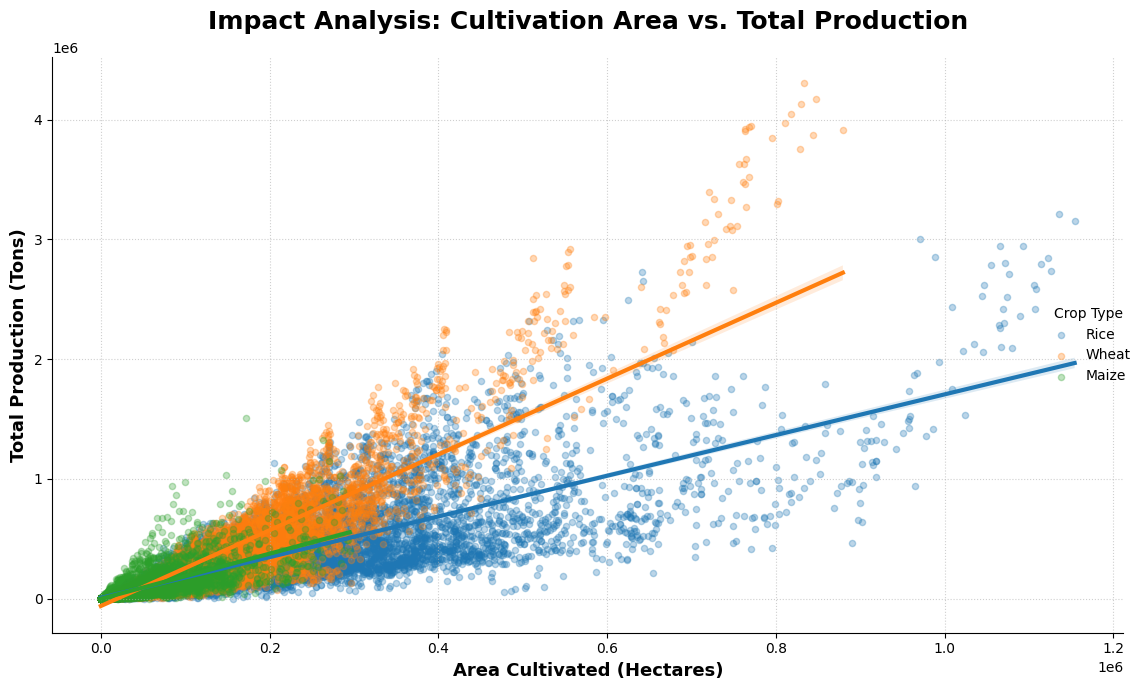

In [36]:
# 14. Impact of Area Cultivated on Production (Rice, Wheat, Maize) (We extract Area and Production for the three crops)

crops = ['rice', 'wheat', 'maize']
temp_list = []

for crop in crops:
    # Create a temporary dataframe for each crop
    c_df = df[[f'{crop}_area', f'{crop}_production']].copy()
    c_df.columns = ['Area', 'Production']
    c_df['Crop Type'] = crop.capitalize()
    temp_list.append(c_df)

# Combine them into one plotting dataframe
impact_df = pd.concat(temp_list)

# 14.1 Create the Figure
plt.figure(figsize=(14, 8))

# 14.2 Create a Scatter Plot with Linear Regression lines
# 'scatter_kws' controls the points, 'line_kws' controls the trendlines
sns.lmplot(data=impact_df, x='Area', y='Production', hue='Crop Type', 
           palette=['#1f77b4', '#ff7f0e', '#2ca02c'], # Rice(Blue), Wheat(Orange), Maize(Green)
           height=7, aspect=1.5, scatter_kws={'alpha':0.3, 's':20}, line_kws={'linewidth':3})

# 14.3 Professional Styling
plt.title("Impact Analysis: Cultivation Area vs. Total Production", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Area Cultivated (Hectares)", fontsize=13, fontweight='bold')
plt.ylabel("Total Production (Tons)", fontsize=13, fontweight='bold')

# Add a light grid for easier reading of the scale
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

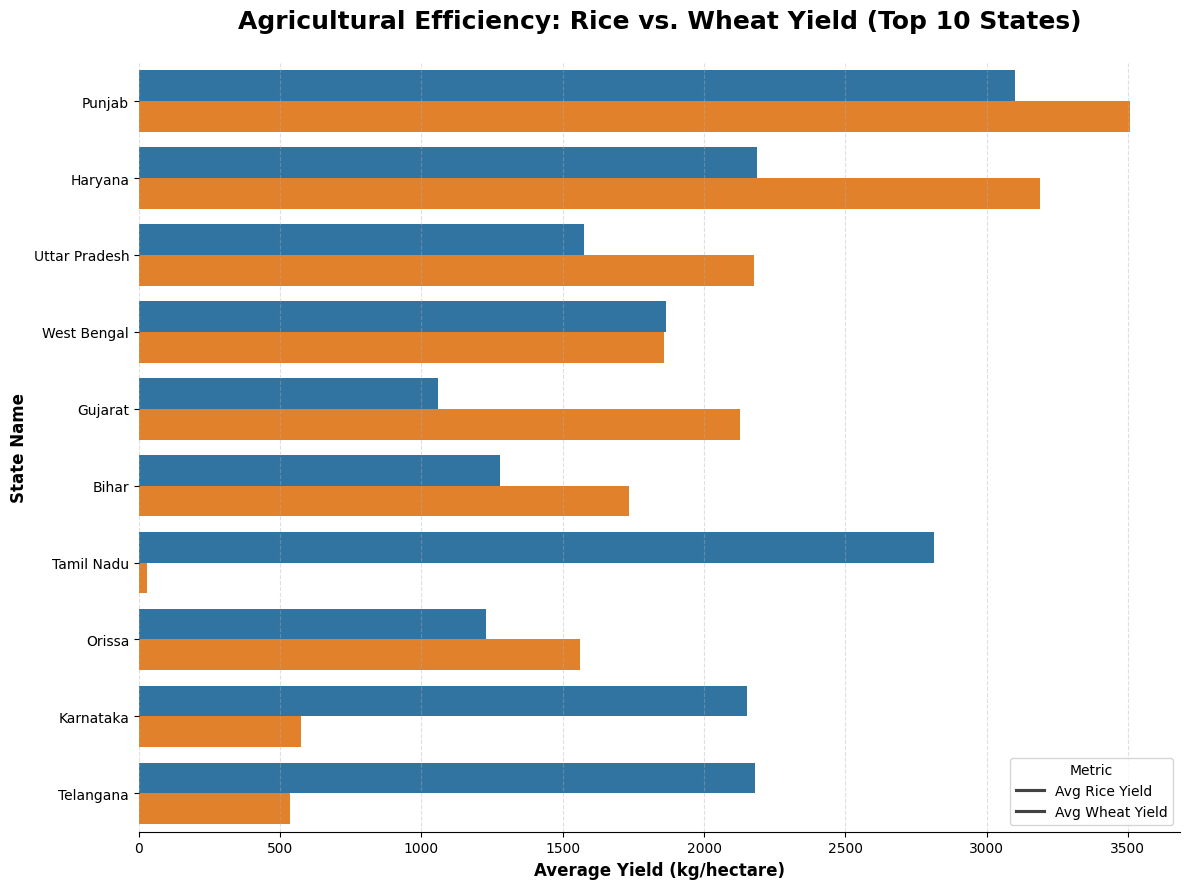

In [37]:
# 15. Rice vs. Wheat Yield Across States (Aggregate mean yield for Rice and Wheat by State)
yield_comp = df.groupby('state_name')[['rice_yield', 'wheat_yield']].mean().reset_index()

# 15.1 Select Top 10 states based on combined yield to show the most efficient regions
yield_comp['total_yield_score'] = yield_comp['rice_yield'] + yield_comp['wheat_yield']
top_10_yield = yield_comp.sort_values('total_yield_score', ascending=False).head(10)

# 15.2 Reshape for plotting (Melt)
yield_melted = top_10_yield.melt(id_vars='state_name', 
                                 value_vars=['rice_yield', 'wheat_yield'], 
                                 var_name='Crop Type', value_name='Average Yield')

# 15.3 Create the Figure
plt.figure(figsize=(12, 9))

# 15.4 Plotting (Using Rice-Blue and Wheat-Orange)
sns.barplot(data=yield_melted, y='state_name', x='Average Yield', hue='Crop Type', 
            palette=['#1f77b4', '#ff7f0e'])

# 15.5 Professional Styling
plt.title('Agricultural Efficiency: Rice vs. Wheat Yield (Top 10 States)', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Average Yield (kg/hectare)', fontsize=12, fontweight='bold')
plt.ylabel('State Name', fontsize=12, fontweight='bold')

# Customize Legend
plt.legend(title='Metric', labels=['Avg Rice Yield', 'Avg Wheat Yield'], frameon=True, loc='lower right')

# Add a light grid for the X-axis only to help guide the eye
plt.grid(axis='x', linestyle='--', alpha=0.4)
sns.despine(left=True)

plt.tight_layout()
plt.show()